# 04. Compare Models

저장된 `MLP`, `LSTM` 결과와 baseline을 함께 비교합니다.

In [1]:

%matplotlib inline

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str((OUTPUT_DIR / '.mplconfig').resolve()))
(OUTPUT_DIR / '.mplconfig').mkdir(parents=True, exist_ok=True)


In [2]:
def print_section(title: str) -> None:
    # 구간 출력
    line = '=' * 50
    print('\n' + line)
    print(title)
    print(line)


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    # 성능 계산
    y_pred = (np.asarray(y_prob) >= threshold).astype(np.int32)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'fpr': fpr,
        'tpr': tpr,
    }


def save_json(path: Path, payload: dict) -> None:
    # json 저장
    with open(path, 'w', encoding='utf-8') as file:
        json.dump(payload, file, ensure_ascii=False, indent=2)


def load_data() -> dict:
    # 비교 데이터 로드
    print_section('[INFO] 비교 데이터 로드')
    sample_path = OUTPUT_DIR / 'samples.csv'
    mlp_metric_path = OUTPUT_DIR / 'mlp_metrics.json'
    lstm_metric_path = OUTPUT_DIR / 'lstm_metrics.json'
    if not sample_path.exists():
        raise FileNotFoundError('먼저 01_prepare_data.ipynb를 실행하세요.')
    if not mlp_metric_path.exists():
        raise FileNotFoundError('먼저 02_train_mlp.ipynb를 실행하세요.')
    if not lstm_metric_path.exists():
        raise FileNotFoundError('먼저 03_train_lstm.ipynb를 실행하세요.')

    samples = pd.read_csv(sample_path)
    feature_columns = [column for column in samples.columns if column.startswith('hist_')]
    train_frame = samples.loc[samples['split'] == 'train'].copy()
    val_frame = samples.loc[samples['split'] == 'val'].copy()
    test_frame = samples.loc[samples['split'] == 'test'].copy()
    scaler = StandardScaler()
    x_train = scaler.fit_transform(train_frame[feature_columns].to_numpy(dtype=np.float32))
    x_test = scaler.transform(test_frame[feature_columns].to_numpy(dtype=np.float32))
    return {
        'x_train': x_train,
        'y_train': train_frame['label'].to_numpy(dtype=np.int32),
        'x_test': x_test,
        'y_test': test_frame['label'].to_numpy(dtype=np.int32),
        'mlp_payload': json.load(open(mlp_metric_path, 'r', encoding='utf-8')),
        'lstm_payload': json.load(open(lstm_metric_path, 'r', encoding='utf-8')),
    }


def train_baselines(data: dict) -> tuple[dict, dict]:
    # baseline 학습
    dummy = DummyClassifier(strategy='prior')
    dummy.fit(data['x_train'], data['y_train'])
    dummy_prob = dummy.predict_proba(data['x_test'])[:, 1]
    dummy_metrics = compute_metrics(data['y_test'], dummy_prob)

    logistic = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
    logistic.fit(data['x_train'], data['y_train'])
    logistic_prob = logistic.predict_proba(data['x_test'])[:, 1]
    logistic_metrics = compute_metrics(data['y_test'], logistic_prob)
    return (
        {'model_name': 'DummyClassifier', 'metrics': dummy_metrics, 'y_prob': dummy_prob},
        {'model_name': 'LogisticRegression', 'metrics': logistic_metrics, 'y_prob': logistic_prob},
    )



[INFO] 비교 데이터 로드



[INFO] Baseline 비교


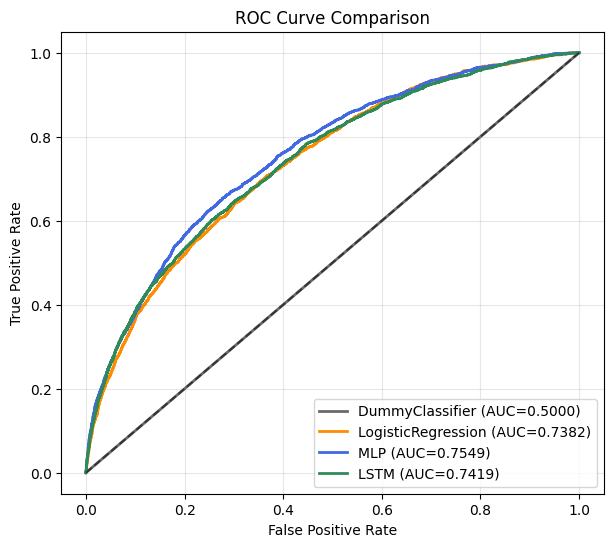

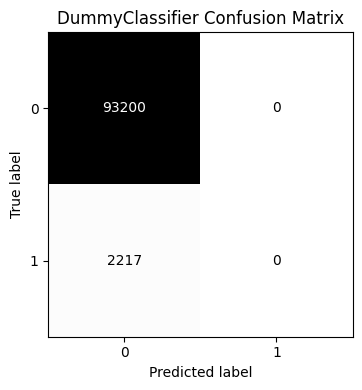

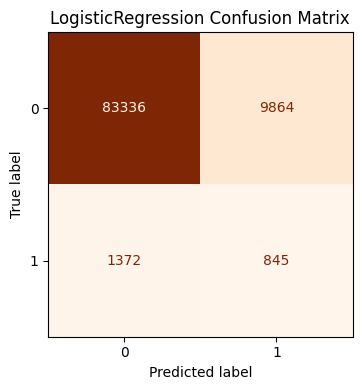

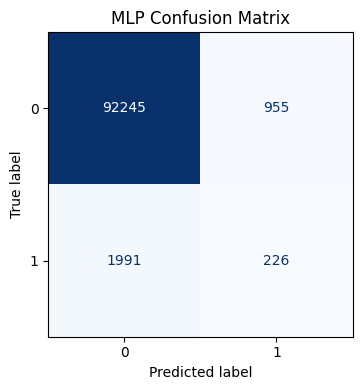

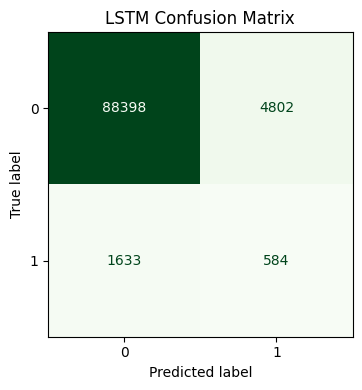


[RESULT] 최종 비교


,model_name,accuracy,precision,recall,f1_score,roc_auc
0,LSTM,0.9326,0.1084,0.2634,0.1536,0.7419
1,MLP,0.9691,0.1914,0.1019,0.1330,0.7549
2,LogisticRegression,0.8822,0.0789,0.3811,0.1307,0.7382
3,DummyClassifier,0.9768,0.0000,0.0000,0.0000,0.5000


MLP threshold: 0.55
LSTM threshold: 0.63
가장 적합한 모델: LSTM
출력 경로: /Users/jsh/Desktop/class/3-1/딥러닝응용/고빈도 고객 재구매 지연 위험 예측/outputs


In [3]:
# 실행
data = load_data()
print_section('[INFO] Baseline 비교')
dummy_result, logistic_result = train_baselines(data)

mlp_pred = pd.read_csv(OUTPUT_DIR / data['mlp_payload']['prediction_path'])
lstm_pred = pd.read_csv(OUTPUT_DIR / data['lstm_payload']['prediction_path'])
mlp_threshold = float(data['mlp_payload'].get('threshold', 0.5))
lstm_threshold = float(data['lstm_payload'].get('threshold', 0.5))
mlp_metrics = compute_metrics(mlp_pred['y_true'].to_numpy(dtype=np.int32), mlp_pred['y_prob'].to_numpy(dtype=np.float32), threshold=mlp_threshold)
lstm_metrics = compute_metrics(lstm_pred['y_true'].to_numpy(dtype=np.int32), lstm_pred['y_prob'].to_numpy(dtype=np.float32), threshold=lstm_threshold)

summary_df = pd.DataFrame([
    {'model_name': 'DummyClassifier', **{k: v for k, v in dummy_result['metrics'].items() if k not in ['confusion_matrix', 'fpr', 'tpr']}},
    {'model_name': 'LogisticRegression', **{k: v for k, v in logistic_result['metrics'].items() if k not in ['confusion_matrix', 'fpr', 'tpr']}},
    {'model_name': 'MLP', **{k: v for k, v in mlp_metrics.items() if k not in ['confusion_matrix', 'fpr', 'tpr']}},
    {'model_name': 'LSTM', **{k: v for k, v in lstm_metrics.items() if k not in ['confusion_matrix', 'fpr', 'tpr']}},
]).sort_values(['f1_score', 'roc_auc'], ascending=False).reset_index(drop=True)
summary_df.to_csv(OUTPUT_DIR / 'comparison_summary.csv', index=False)

save_json(OUTPUT_DIR / 'baseline_metrics.json', {
    'models': [
        {'model_name': 'DummyClassifier', 'aggregate': {f'{metric}_mean': dummy_result['metrics'][metric] for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']}},
        {'model_name': 'LogisticRegression', 'aggregate': {f'{metric}_mean': logistic_result['metrics'][metric] for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']}},
    ]
})

with open(OUTPUT_DIR / 'final_summary.txt', 'w', encoding='utf-8') as file:
    best_row = summary_df.iloc[0]
    file.write('\n'.join([
        f"가장 적합한 모델: {best_row['model_name']}",
        f"Accuracy: {best_row['accuracy']:.4f}",
        f"Precision: {best_row['precision']:.4f}",
        f"Recall: {best_row['recall']:.4f}",
        f"F1-score: {best_row['f1_score']:.4f}",
        f"ROC-AUC: {best_row['roc_auc']:.4f}",
    ]))

fig, ax = plt.subplots(figsize=(7, 6))
for model_name, metrics, color in [
    ('DummyClassifier', dummy_result['metrics'], 'dimgray'),
    ('LogisticRegression', logistic_result['metrics'], 'darkorange'),
    ('MLP', mlp_metrics, 'royalblue'),
    ('LSTM', lstm_metrics, 'seagreen'),
]:
    ax.plot(metrics['fpr'], metrics['tpr'], linewidth=2, color=color, label=f"{model_name} (AUC={metrics['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

for model_name, metrics, cmap in [
    ('DummyClassifier', dummy_result['metrics'], 'Greys'),
    ('LogisticRegression', logistic_result['metrics'], 'Oranges'),
    ('MLP', mlp_metrics, 'Blues'),
    ('LSTM', lstm_metrics, 'Greens'),
]:
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(metrics['confusion_matrix']).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

print_section('[RESULT] 최종 비교')
display(summary_df.round(4))
print(f'MLP threshold: {mlp_threshold:.2f}')
print(f'LSTM threshold: {lstm_threshold:.2f}')
print(f"가장 적합한 모델: {summary_df.iloc[0]['model_name']}")
print('출력 경로:', OUTPUT_DIR.resolve())
